In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from PIL import Image
from glob import glob
import timm
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
class AlzheimerDataset(Dataset):
    def __init__(self, root, data_type, transform=None):
        self.transform = transform
        self.im_paths = glob(f"{root}/{data_type}/*/*.*")
        self.classes = sorted({os.path.basename(os.path.dirname(p)) for p in self.im_paths})
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        img_path = self.im_paths[idx]
        img = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[os.path.basename(os.path.dirname(img_path))]
        if self.transform:
            img = self.transform(img)
        return img, label


In [3]:
root = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
transform = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])

# Load FULL train dataset
train_dataset = AlzheimerDataset(root, "train", transform)

# Split train dataset into actual train and validation
train_len = int(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_ds, val_ds = random_split(train_dataset, [train_len, val_len])

# Create DataLoaders
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

# Compute TRAIN class counts from train_ds
from collections import Counter

train_class_counts = Counter()
for img, label in train_ds:
    class_name = train_dataset.classes[label]
    train_class_counts[class_name] += 1

# Compute VALIDATION class counts from val_ds
val_class_counts = Counter()
for img, label in val_ds:
    class_name = train_dataset.classes[label]
    val_class_counts[class_name] += 1

# Load and compute TEST class counts
test_dataset = AlzheimerDataset(root, "test", transform)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)

test_class_counts = Counter()
for _, label in test_dataset:
    class_name = test_dataset.classes[label]
    test_class_counts[class_name] += 1

# Final output for checking
print("Train Class Counts:", train_class_counts)
print("Validation Class Counts:", val_class_counts)
print("Test Class Counts:", test_class_counts)

# Total samples before split
print(f"\nTotal samples in full train set (before split): {len(train_dataset)}")

# Total samples after split
print(f"Samples in training split: {len(train_ds)}")
print(f"Samples in validation split: {len(val_ds)}")

# Sanity check: Sum should match original
assert len(train_ds) + len(val_ds) == len(train_dataset), "Split mismatch!"


# Combine counts into a list for visualization
cls_counts = [train_class_counts, val_class_counts, test_class_counts]

# Class Names
print(f"Classes: {train_dataset.classes}")


Train Class Counts: Counter({'Moderate Impairment': 2061, 'Mild Impairment': 2048, 'No Impairment': 2042, 'Very Mild Impairment': 2041})
Validation Class Counts: Counter({'Very Mild Impairment': 519, 'No Impairment': 518, 'Mild Impairment': 512, 'Moderate Impairment': 499})
Test Class Counts: Counter({'No Impairment': 640, 'Very Mild Impairment': 448, 'Mild Impairment': 179, 'Moderate Impairment': 12})

Total samples in full train set (before split): 10240
Samples in training split: 8192
Samples in validation split: 2048
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


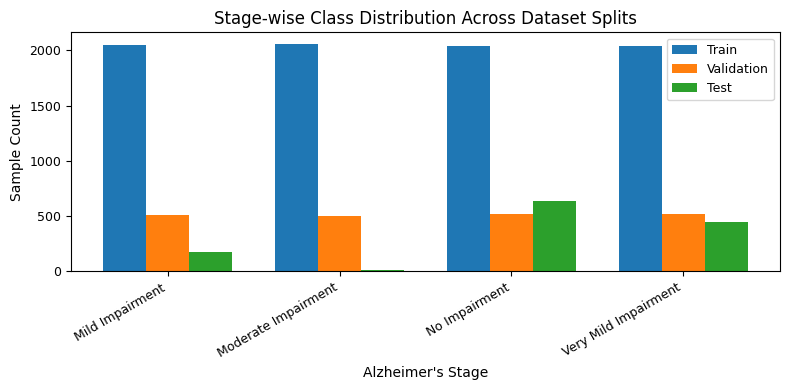

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Class names in consistent order
class_names = ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']

# Sample values (replace with actual values if needed)
train_values = [train_class_counts[cls] for cls in class_names]
val_values = [val_class_counts[cls] for cls in class_names]
test_values = [test_class_counts[cls] for cls in class_names]

x = np.arange(len(class_names))
bar_width = 0.25

plt.figure(figsize=(8, 4))  # Wider layout

# Plot bars
plt.bar(x - bar_width, train_values, width=bar_width, label='Train')
plt.bar(x, val_values, width=bar_width, label='Validation')
plt.bar(x + bar_width, test_values, width=bar_width, label='Test')

# Labels & formatting
plt.xlabel("Alzheimer's Stage", fontsize=10)
plt.ylabel("Sample Count", fontsize=10)
plt.title("Stage-wise Class Distribution Across Dataset Splits", fontsize=12)
plt.xticks(ticks=x, labels=class_names, rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()

# Optional: Save the plot
plt.savefig("adjusted_class_distribution.png", dpi=300)

plt.show()


In [5]:
from collections import Counter

# Combine all counts
total_class_counts = Counter()

for cls in train_class_counts:
    total_class_counts[cls] += train_class_counts[cls]

for cls in val_class_counts:
    total_class_counts[cls] += val_class_counts[cls]

for cls in test_class_counts:
    total_class_counts[cls] += test_class_counts[cls]

# Print the totals per class
print("Total Samples per Class (Train + Validation + Test):")
for cls, count in total_class_counts.items():
    print(f"{cls}: {count}")


Total Samples per Class (Train + Validation + Test):
Moderate Impairment: 2572
No Impairment: 3200
Very Mild Impairment: 3008
Mild Impairment: 2739


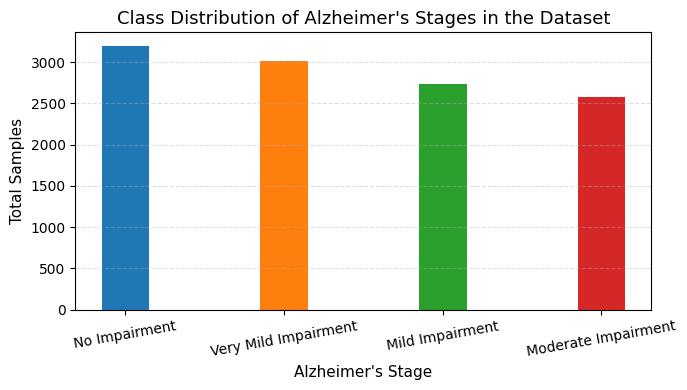

In [6]:
import matplotlib.pyplot as plt

# Ordered class names
class_names = ['No Impairment', 'Very Mild Impairment', 'Mild Impairment', 'Moderate Impairment']

# Matching class counts
total_values = [total_class_counts[cls] for cls in class_names]

# Custom colors
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot
plt.figure(figsize=(7, 4))  # Standard size
plt.bar(class_names, total_values, color=bar_colors, width=0.3)

# Style
plt.title("Class Distribution of Alzheimer's Stages in the Dataset", fontsize=13)
plt.xlabel("Alzheimer's Stage", fontsize=11)
plt.ylabel("Total Samples", fontsize=11)
plt.xticks(rotation=10, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms as T
import seaborn as sns

class Visualization:
    def __init__(self, vis_datas, n_ims, rows, cmap="rgb", cls_names=None, cls_counts=None, t_type="rgb"):
        self.n_ims, self.rows = n_ims, rows
        self.t_type, self.cmap = t_type, cmap
        self.cls_names = cls_names
        self.colors = plt.cm.tab20.colors  # Dynamically handle more classes
        data_names = ["train", "val", "test"]
        self.vis_datas = {data_names[i]: vis_datas[i] for i in range(len(vis_datas))}
        if isinstance(cls_counts, list):
            self.analysis_datas = {data_names[i]: cls_counts[i] for i in range(len(cls_counts))}
        else:
            self.analysis_datas = {"all": cls_counts}

    def tn2np(self, t):
        # Assuming dataset was normalized with mean=0.5, std=0.5
        invTrans = T.Normalize(mean=[-0.5 / 0.5] * 3, std=[1 / 0.5] * 3)
        img = invTrans(t).detach().cpu().permute(1, 2, 0).numpy()
        return np.clip(img, 0, 1)

    def vis(self, data, save_name):
        print(f"{save_name.upper()} Data Visualization in process...\n")
        cols = self.n_ims // self.rows
        plt.figure(figsize=(15, 10))
        indices = [np.random.randint(low=0, high=len(data) - 1) for _ in range(self.n_ims)]
        for idx, index in enumerate(indices):
            image, label = data[index]
            plt.subplot(self.rows, cols, idx + 1)
            plt.imshow(self.tn2np(image))
            plt.axis('off')
            if self.cls_names is not None:
                plt.title(f"GT -> {self.cls_names[int(label)]}")
            else:
                plt.title(f"GT -> {label}")
        plt.show()

    def data_analysis(self, cls_counts, save_name, color):
        print(f"{save_name.upper()} Class Distribution Analysis...\n")
        cls_names = list(cls_counts.keys())
        counts = list(cls_counts.values())
        indices = np.arange(len(counts))
        plt.figure(figsize=(8, 5))
        bars = plt.bar(indices, counts, color=color)
        plt.xlabel("Class Names")
        plt.ylabel("Data Counts")
        plt.title("Dataset Class Imbalance Analysis")
        plt.xticks(ticks=indices, labels=cls_names, rotation=45)
        # Add count labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{int(height)}', ha='center', va='bottom', color='blue')
        plt.tight_layout()
        plt.show()

    def plot_pie_chart(self, cls_counts):
        print("Generating pie chart...\n")
        labels = list(cls_counts.keys())
        sizes = list(cls_counts.values())
        explode = [0.1] * len(labels)
        plt.figure(figsize=(5, 5))
        plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
                startangle=140, colors=plt.cm.tab20.colors)
        plt.title("Class Distribution Pie Chart")
        plt.axis("equal")
        plt.show()

    def visualization(self):
        [self.vis(data.dataset, save_name) for (save_name, data) in self.vis_datas.items()]

    def analysis(self):
        [self.data_analysis(data, save_name, self.colors[i]) for i, (save_name, data) in enumerate(self.analysis_datas.items())]

    def pie_chart(self):
        [self.plot_pie_chart(data) for data in self.analysis_datas.values()]


TRAIN Data Visualization in process...



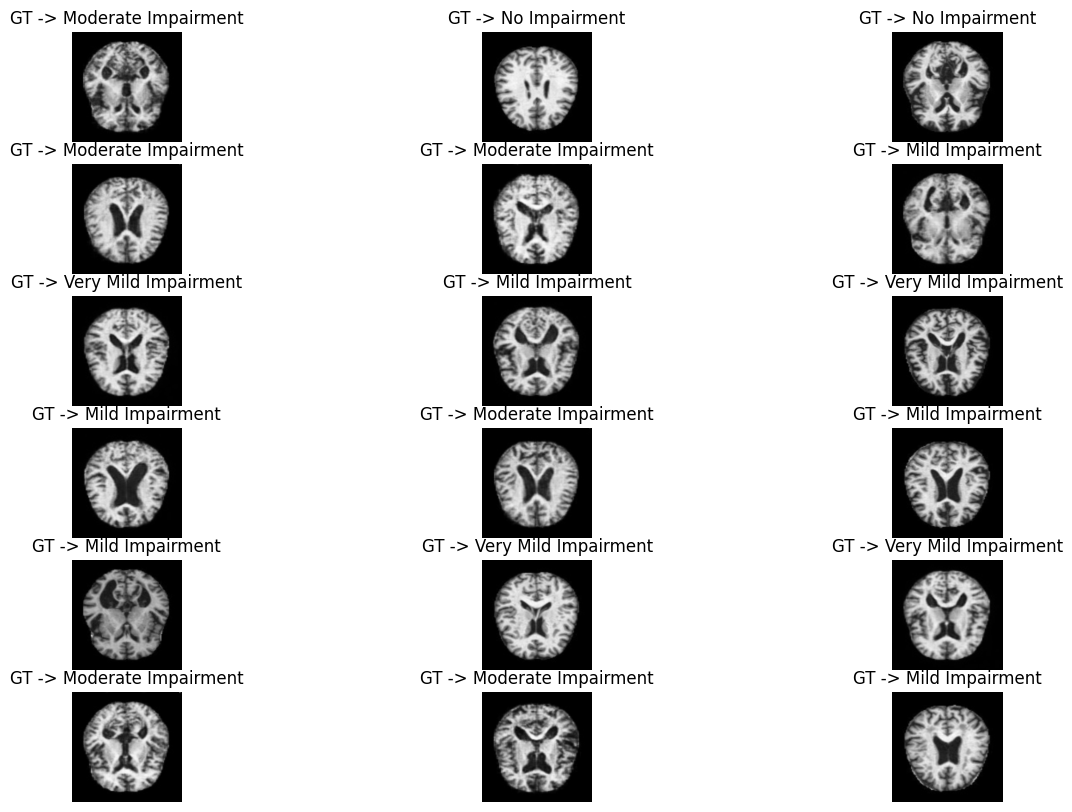

VAL Data Visualization in process...



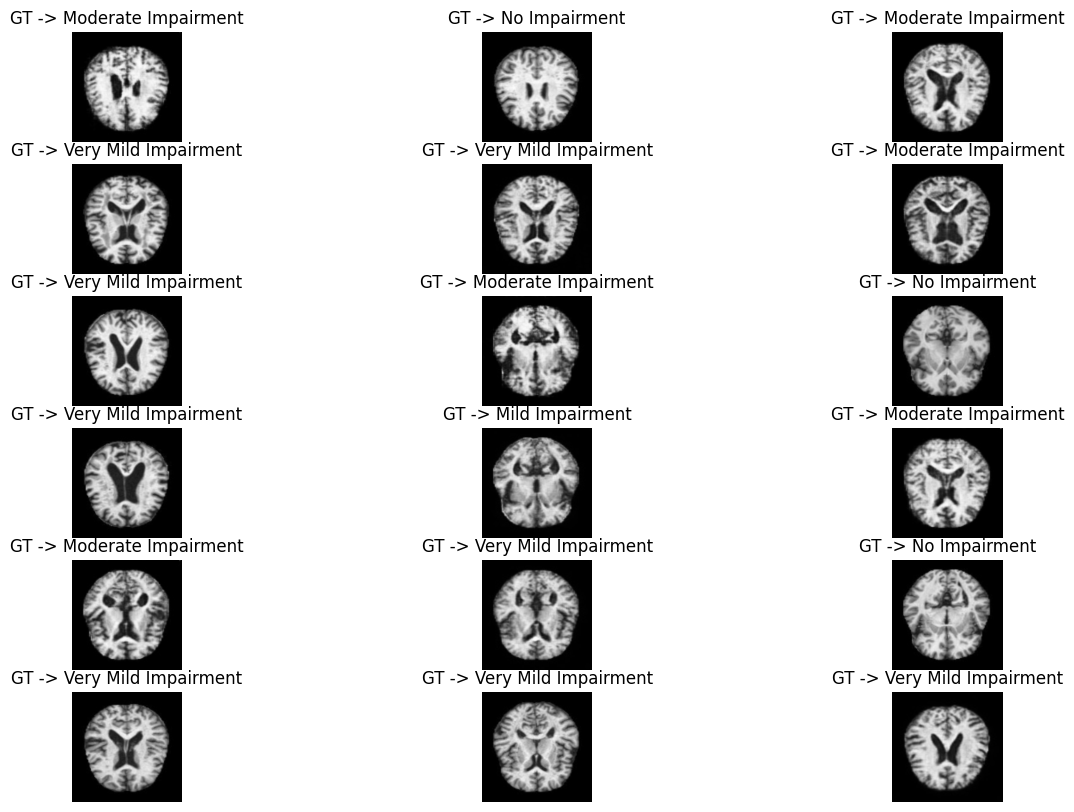

TEST Data Visualization in process...



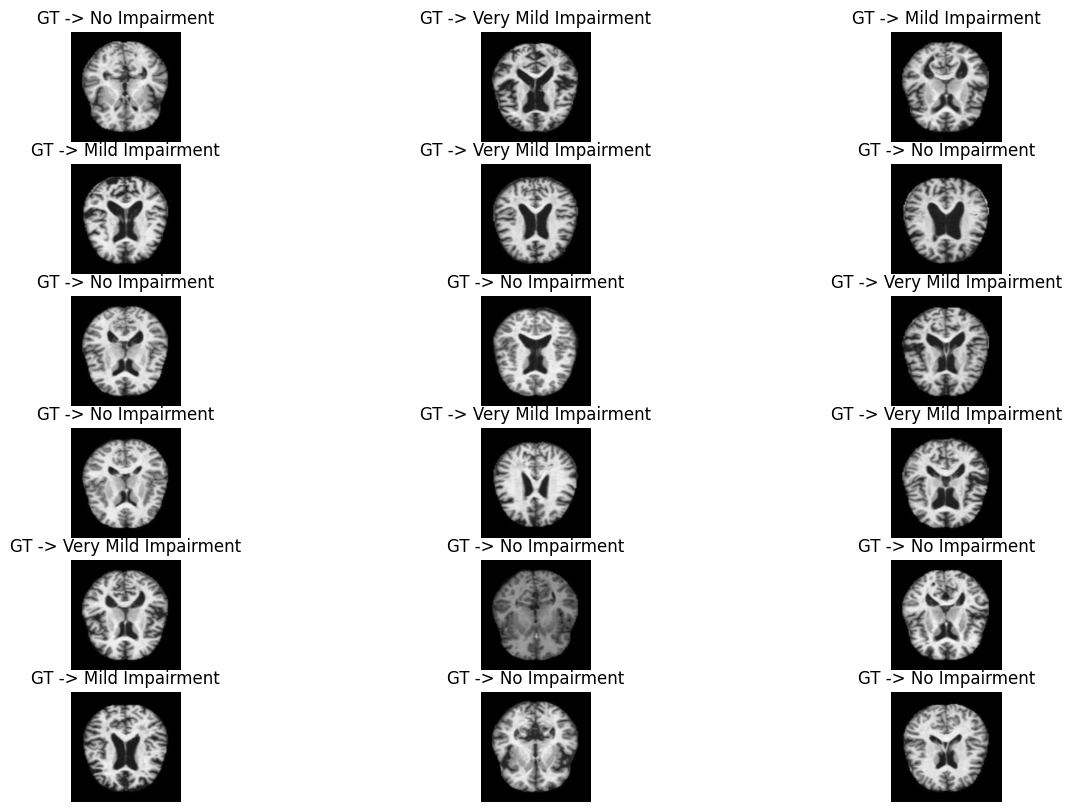

TRAIN Class Distribution Analysis...



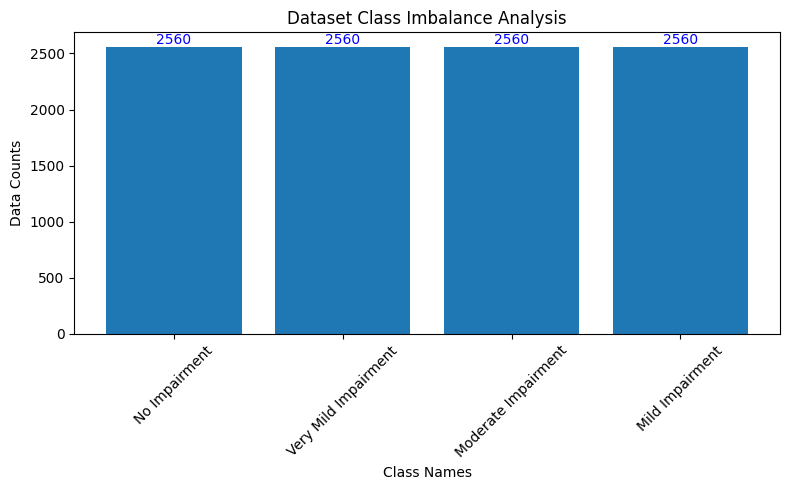

VAL Class Distribution Analysis...



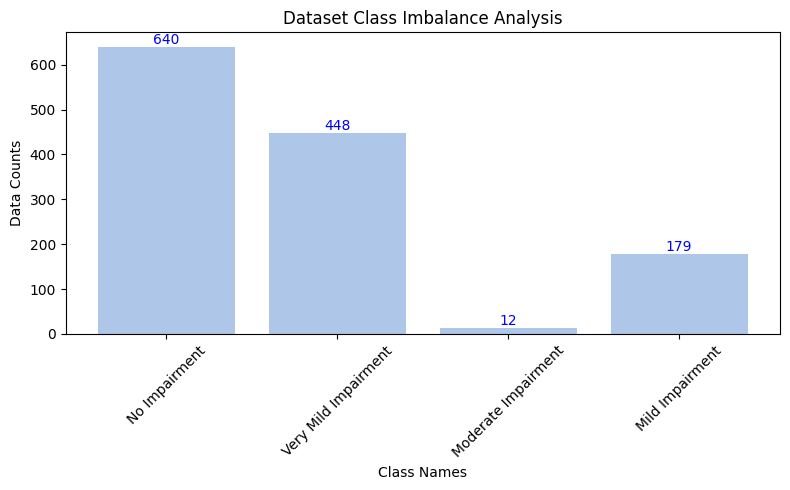

Generating pie chart...



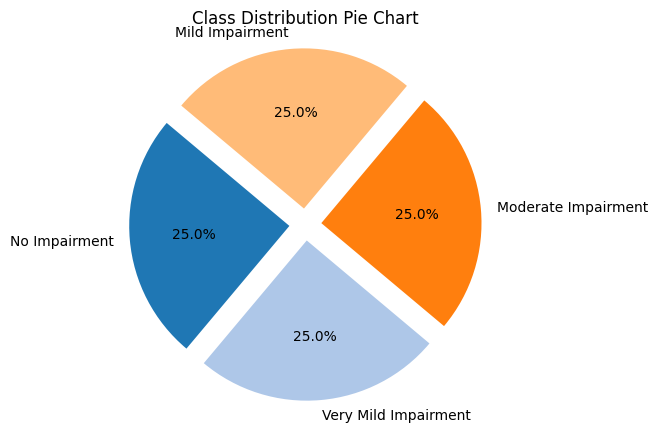

Generating pie chart...



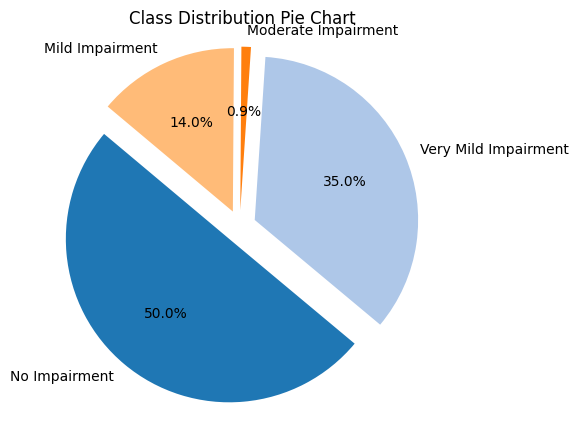

In [8]:
from collections import Counter

# Compute TRAIN class counts
train_class_counts = Counter()
for _, label in train_dataset:
    class_name = train_dataset.classes[label]
    train_class_counts[class_name] += 1

# Compute TEST class counts
test_class_counts = Counter()
for _, label in test_dataset:
    class_name = test_dataset.classes[label]
    test_class_counts[class_name] += 1

# Create the counts list for both train and test
cls_counts = [train_class_counts, test_class_counts]

# Initialize Visualization with the correct cls_counts list
vis = Visualization(
    vis_datas=[train_dl, val_dl, test_dl],
    n_ims=18,
    rows=6,
    cmap="rgb",
    cls_names=train_dataset.classes,
    cls_counts=cls_counts   # ✅ PASS the correct list here
)

#  Show Random Images
vis.visualization()

# Show Class Distribution Bar Chart (plots both train and test)
vis.analysis()

# Show Class Distribution Pie Chart
vis.pie_chart()


In [9]:
print(f"Total Training Samples: {len(train_dl.dataset)}")
print(f"Total Validation Samples: {len(val_dl.dataset)}")
print(f"Total Test Samples: {len(test_dl.dataset)}")


Total Training Samples: 8192
Total Validation Samples: 2048
Total Test Samples: 1279


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('resnet50', pretrained=True, num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [11]:
# import torch
# import torch.optim as optim
# import timm

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load ReXNet-150 with pretrained weights and custom output classes
# model = timm.create_model('rexnet_150', pretrained=True, num_classes=4).to(device)

# # Freeze entire model
# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze only the classification head
# for param in model.head.parameters():
#     param.requires_grad = True

# # Loss function and optimizer (only the head's parameters are trainable)
# criterion = torch.nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.head.parameters(), lr=1e-4)


In [12]:
# import torch
# import torch.optim as optim
# import timm

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load ReXNet-150 with pretrained weights and 4 output classes
# model = timm.create_model('rexnet_150', pretrained=True, num_classes=4).to(device)

# # Freeze entire model first
# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze the last few blocks (adjust depending on number of blocks in ReXNet)
# for name, param in model.named_parameters():
#     if 'blocks.20' in name or 'blocks.21' in name or 'blocks.22' in name or 'head' in name:
#         param.requires_grad = True

# # Confirm which layers are trainable
# print("Trainable layers:")
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(name)

# # Define loss function
# criterion = torch.nn.CrossEntropyLoss()

# # Optimizer: Only train the unfrozen layers
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)


Epoch 1/20: 100%|██████████| 256/256 [01:10<00:00,  3.65it/s]


Epoch 1 -> Train Loss: 0.6120, Train Acc: 0.7321, Val Loss: 0.5772, Val Acc: 0.7646
Model saved at epoch 1


Epoch 2/20: 100%|██████████| 256/256 [01:10<00:00,  3.65it/s]


Epoch 2 -> Train Loss: 0.2493, Train Acc: 0.9030, Val Loss: 0.3647, Val Acc: 0.8511
Model saved at epoch 2


Epoch 3/20: 100%|██████████| 256/256 [01:09<00:00,  3.68it/s]


...

Epoch 7 -> Train Loss: 0.0233, Train Acc: 0.9917, Val Loss: 0.1893, Val Acc: 0.9434


Epoch 8/20: 100%|██████████| 256/256 [01:04<00:00,  3.98it/s]


Epoch 8 -> Train Loss: 0.0287, Train Acc: 0.9896, Val Loss: 0.1995, Val Acc: 0.9355


Epoch 9/20: 100%|██████████| 256/256 [01:04<00:00,  3.98it/s]


Epoch 9 -> Train Loss: 0.0214, Train Acc: 0.9928, Val Loss: 0.1440, Val Acc: 0.9536
Early stopping triggered.

Training Completed. Best model saved at: saved_models/mri_best_model.pth


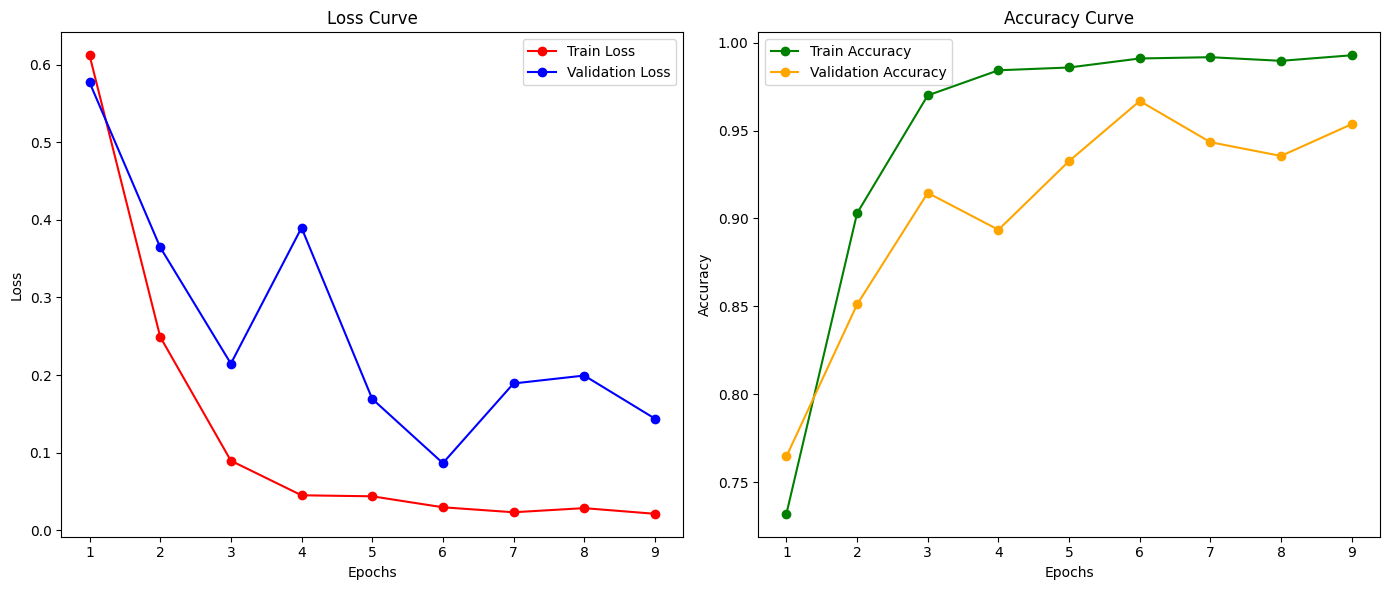

In [13]:
import os
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# ✅ Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Create save directory
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "mri_best_model.pth")

# ✅ Lists to store loss and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ✅ Training parameters
epochs = 20
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0
min_delta = 0.001

for epoch in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_dl.dataset)
    train_losses.append(total_loss / len(train_dl))
    train_accuracies.append(train_acc)

    # Validation loop
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            val_loss += criterion(output, labels).item()
            val_correct += (output.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dl.dataset)
    val_losses.append(val_loss / len(val_dl))
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} -> Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.4f}")

    # Model checkpoint
    if val_losses[-1] < best_val_loss - min_delta:
        best_val_loss = val_losses[-1]
        epochs_no_improve = 0
        torch.save(model.state_dict(), save_path)
        print(f"Model saved at epoch {epoch+1}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

print(f"\nTraining Completed. Best model saved at: {save_path}")

# Final Loss and Accuracy Curve Plot (with your styling)
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss", color='red', marker='o')
plt.plot(epochs_range, val_losses, label="Validation Loss", color='blue', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.xticks(epochs_range)
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color='green', marker='o')
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", color='orange', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.xticks(epochs_range)
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
from collections import Counter
test_classes = []
for _, labels in test_dl:
    test_classes.extend(labels.numpy())
print(Counter(test_classes))


Counter({2: 640, 3: 448, 0: 179, 1: 12})


In [15]:
# model.eval()
# test_correct = 0
# test_loss = 0

# with torch.no_grad():
#     for imgs, labels in test_dl:
#         imgs, labels = imgs.to(device), labels.to(device)
#         output = model(imgs)
        
#         # Calculate loss
#         loss = criterion(output, labels)
#         test_loss += loss.item()
        
#         # Calculate accuracy
#         test_correct += (output.argmax(1) == labels).sum().item()

# # Calculate average loss and accuracy
# avg_test_loss = test_loss / len(test_dl)
# test_accuracy = test_correct / len(test_dl.dataset)

# print(f"Test Loss: {avg_test_loss:.4f}")
# print(f"Test Accuracy: {test_accuracy:.4f}")


In [16]:
%matplotlib inline


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.6-py3-none-any.whl size=38339 sha256=bc02bfcc17890b48c7dec932852564f8e1f1856ac1843adeb836d8dc55cf2f57
  Stored in directory: /root/.cache/pip/wheels/3c/6c/04/9a543775e9f25f6c441180a552456f1696167439459730ff87
Successfully built grad-cam
Test dataset samples: 1279


<ipython-input-17-540b1b812b3a>:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/{save_prefix}_best_model.pth"))


Running Full Inference and Visualization...
Starting Inference Loop...


Inference: 100%|██████████| 40/40 [00:05<00:00,  7.22it/s]


Accuracy on test data -> 0.937


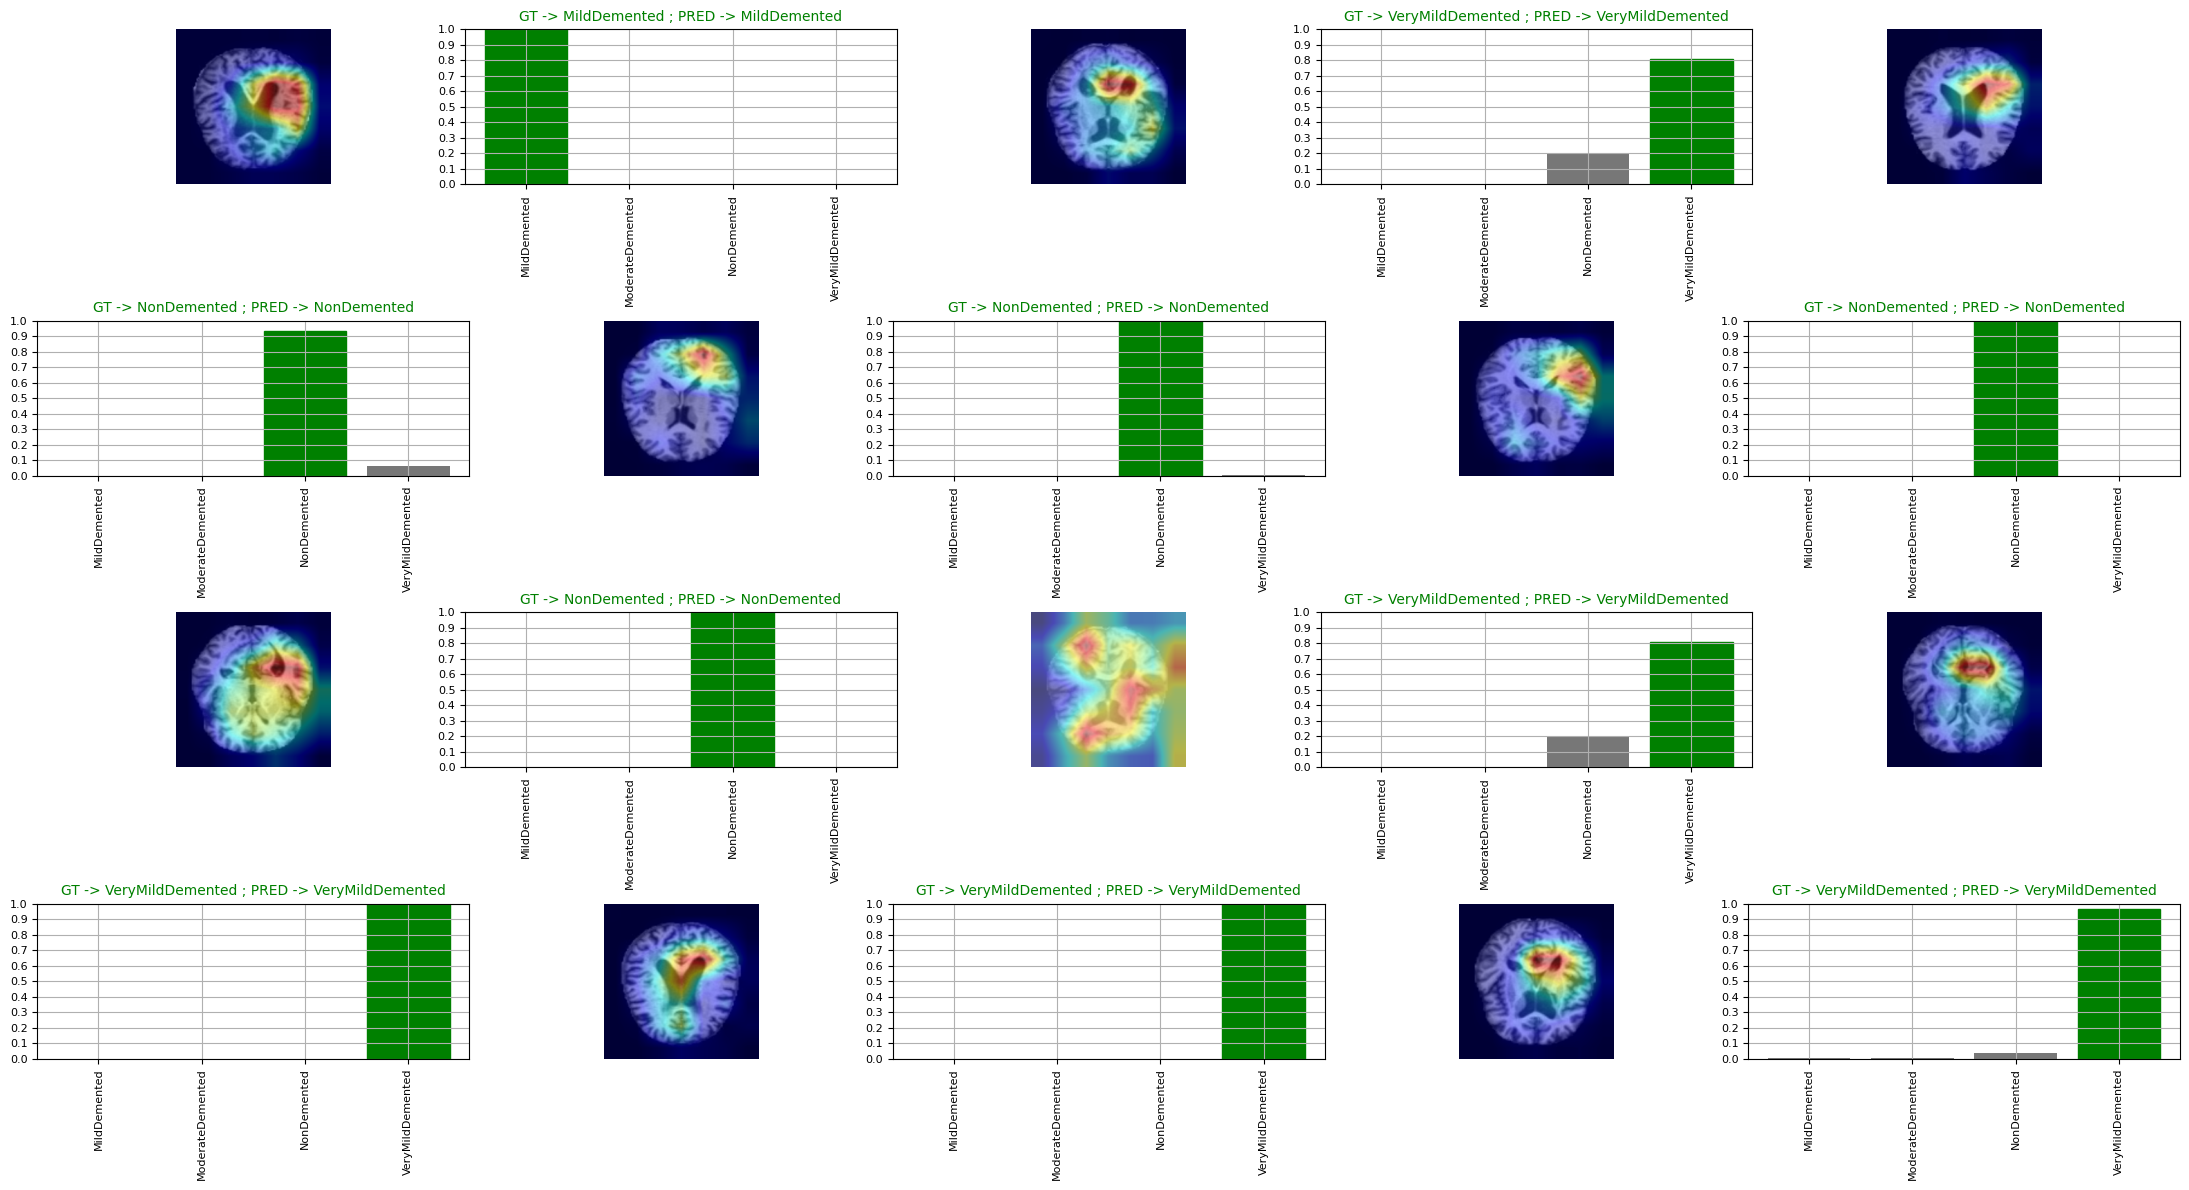

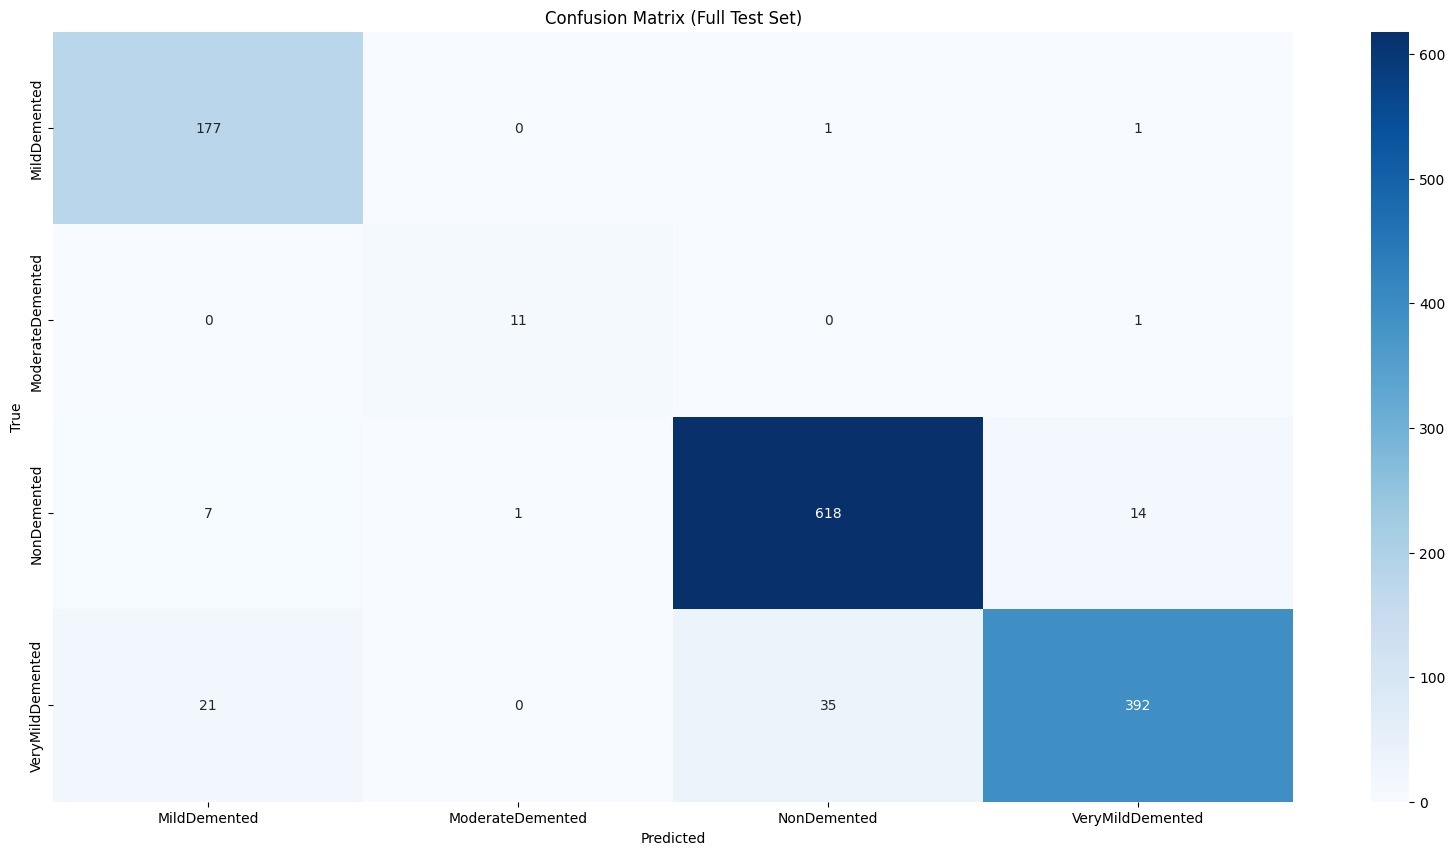


Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.86      0.99      0.92       179
ModerateDemented       0.92      0.92      0.92        12
     NonDemented       0.94      0.97      0.96       640
VeryMildDemented       0.96      0.88      0.92       448

        accuracy                           0.94      1279
       macro avg       0.92      0.94      0.93      1279
    weighted avg       0.94      0.94      0.94      1279



In [17]:
!pip install grad-cam==1.4.6

import cv2, random
import seaborn as sns
import torch
import numpy as np
import matplotlib.pyplot as plt
import timm
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# ✅ Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Model and dataset details
model_name = "resnet50"
save_dir = "saved_models"
save_prefix = "mri"
im_size = 224
classes = {"MildDemented": 0, "ModerateDemented": 1, "NonDemented": 2, "VeryMildDemented": 3}

print(f"Test dataset samples: {len(test_dl.dataset)}")

# ✅ Denormalization helper
class Denormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

# ✅ Visualization class
class ModelInferenceVisualizer:
    def __init__(self, model, device, class_names=None, im_size=224, mean=None, std=None):
        self.denormalize = Denormalize(mean, std)
        self.model = model
        self.device = device
        self.class_names = class_names
        self.im_size = im_size
        self.model.eval()

    def tensor_to_image(self, tensor):
        tensor = self.denormalize(tensor)
        tensor = tensor.permute(1, 2, 0)
        return (tensor.cpu().numpy() * 255).astype(np.uint8)

    def plot_value_array(self, logits, gt, class_names):
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1)
        plt.grid(True)
        plt.xticks(range(len(class_names)), class_names, rotation='vertical', fontsize=8)
        plt.yticks(np.arange(0.0, 1.1, 0.1), fontsize=8)
        bars = plt.bar(range(len(class_names)), [p.item() for p in probs[0]], color="#777777")
        plt.ylim([0, 1])
        if pred_class.item() == gt:
            bars[pred_class].set_color('green')
        else:
            bars[pred_class].set_color('red')

    def generate_cam_visualization(self, image_tensor, gt_label):
        cam = GradCAMPlusPlus(
            model=self.model,
            target_layers=[self.model.layer4[-1]],  # ✅ Correct for ResNet
            use_cuda=(self.device.type == "cuda")
        )
        targets = [ClassifierOutputTarget(gt_label)]
        grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0), targets=targets)[0, :]
        return grayscale_cam

    def infer_and_visualize(self, test_dl, num_images=10, rows=2):
        preds, images, lbls, logitss = [], [], [], []
        all_preds, all_lbls = [], []
        accuracy, count = 0, 1

        print("Starting Inference Loop...")
        with torch.no_grad():
            for idx, batch in tqdm(enumerate(test_dl), total=len(test_dl), desc="Inference"):
                im, gt = batch
                im, gt = im.to(self.device), gt.to(self.device)

                logits = self.model(im)
                pred_class = torch.argmax(logits, dim=1)
                accuracy += (pred_class == gt).sum().item()

                all_preds.extend(pred_class.cpu().numpy())
                all_lbls.extend(gt.cpu().numpy())

                images.append(im[0])
                logitss.append(logits[0])
                preds.append(pred_class[0].item())
                lbls.append(gt[0].item())

        print(f"Accuracy on test data -> {(accuracy / len(test_dl.dataset)):.3f}")

        # ✅ Grad-CAM visualizations
        plt.figure(figsize=(22, 12))
        indices = [random.randint(0, len(images) - 1) for _ in range(num_images)]
        for idx, index in enumerate(indices):
            im = self.tensor_to_image(images[index].squeeze())
            pred_idx = preds[index]
            gt_idx = lbls[index]

            plt.subplot(rows, 2 * num_images // rows, count)
            count += 1
            plt.imshow(im)
            plt.axis("off")

            grayscale_cam = self.generate_cam_visualization(images[index], gt_idx)
            visualization = show_cam_on_image(im / 255, grayscale_cam, image_weight=0.4, use_rgb=True)
            plt.imshow(cv2.resize(visualization, (self.im_size, self.im_size)), alpha=0.7, cmap='jet')
            plt.axis("off")

            logits = logitss[index]
            if logits.dim() == 1:
                logits = logits.unsqueeze(0)
            plt.subplot(rows, 2 * num_images // rows, count)
            count += 1
            self.plot_value_array(logits=logits, gt=gt_idx, class_names=self.class_names)

            if self.class_names:
                gt_name = self.class_names[gt_idx]
                pred_name = self.class_names[pred_idx]
                color = "green" if gt_name == pred_name else "red"
                plt.title(f"GT -> {gt_name} ; PRED -> {pred_name}", color=color, fontsize=10)

        plt.tight_layout()
        plt.show()

        # ✅ Confusion Matrix
        plt.figure(figsize=(20, 10))
        cm = confusion_matrix(all_lbls, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.class_names, yticklabels=self.class_names, cmap='Blues')
        plt.title("Confusion Matrix (Full Test Set)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # ✅ Classification Report
        print("\nClassification Report:\n")
        print(classification_report(all_lbls, all_preds, target_names=self.class_names))

#########################################
# ✅ Load your trained model
model = timm.create_model(model_name=model_name, pretrained=True, num_classes=len(classes)).to(device)
model.load_state_dict(torch.load(f"{save_dir}/{save_prefix}_best_model.pth"))

#########################################
# ✅ Create visualizer and run it
inference_visualizer = ModelInferenceVisualizer(
    model=model,
    device=device,
    class_names=list(classes.keys()),
    im_size=im_size,
    mean=[0.5, 0.5, 0.5],
    std=[0.5, 0.5, 0.5]
)

print("Running Full Inference and Visualization...")
inference_visualizer.infer_and_visualize(test_dl, num_images=10, rows=4)
